In [84]:
%env ASTERIA=/home/jakob/software/NEW_ASTERIA/ASTERIA

import sys
from pathlib import Path

import numpy as np
from astropy import units as u
import matplotlib.pyplot as plt

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

from asteria.simulation import Simulation
from scripts.analysis import Analysis

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
plt.rcParams["font.family"] = "Times New Roman"

plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'   # Roman
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'  # Italic
plt.rcParams['mathtext.bf'] = 'Times New Roman:bold'    # Bold

#plt.rcParams["text.usetex"] = True
plt.rcParams["font.size"] = 16
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

env: ASTERIA=/home/jakob/software/NEW_ASTERIA/ASTERIA


In [155]:
add_wls = True
detector_scope = "Gen2"

trials = 100000
distance = 10*u.kpc

# template parameters
frequency =80*u.Hz
amplitude = None
time_start = None
time_end = None
position = "center"

sim_dt = 1 * u.ms
res_dt = 1 * u.ms
time_win = [0, 0.4] * u.s # time independent
freq_res = 1 * u.Hz 
freq_win = [75, 1E6] * u.Hz # freq independent
hanning = False

temp_para = {"frequency": frequency, 
             "amplitude": amplitude, #in percent of max value
             "time_start": time_start,
             "time_end": time_end,
             "position": position}

fft_para = {"time_res": res_dt, 
             "time_win": time_win,
             "freq_res": freq_res,
             "freq_win": freq_win,
             "hanning": hanning}


model = {'name': 'Tamborra_2014',
         'param':{
             'progenitor_mass': 20*u.Msun, 
             'direction': 1}
        }

np.random.seed(5)

sim = Simulation(model=model,
                 distance=10*u.kpc, 
                 res_dt=res_dt,
                 Emin=0*u.MeV, Emax=100*u.MeV, dE=1*u.MeV,
                 tmin=0.000*u.s, tmax=0.338*u.s, dt=sim_dt,
                 hierarchy = 'normal',
                 mixing_scheme = 'NoTransformation',
                 detector_scope = detector_scope,
                 add_wls = add_wls)
sim.run()

In [ ]:
# Initialize analysis class and run analysis
ana = Analysis(sim, res_dt = res_dt, distance=distance, temp_para=temp_para)
ana.run(mode = "FFT", ft_para = fft_para, trials = trials, model = "model")

Binning in _signal_model: 12


In [145]:
from scipy.fft import fftfreq, fft

def apply_fmask(freq, fft, freq_win):
        
    freq_low, freq_high = freq_win
    fmask = np.logical_and(freq>=freq_low, freq<=freq_high) # frequency mask

    fft_new = fft[fmask]
            
    freq_new = freq[fmask] # new frequency array
    flength_new = len(freq_new) # new length of frequency array

    return fft_new, freq_new, flength_new

def apply_tmask(time, hits, time_win):
        
    time_low, time_high = time_win
    tmask = np.logical_and(time>=time_low, time<=time_high) # time mask

    hits_new = hits[tmask]
            
    time_new = time[tmask] # new frequency array
    tlength_new = len(time_new) # new length of frequency array

    return hits_new, time_new, tlength_new

def get_fft(time, hits, fft_para):

        time_win = fft_para["time_win"]
        freq_win = fft_para["freq_win"]
        res_dt = fft_para["time_res"]
        
        _hits_new, _time_new, _tlength_new = apply_tmask(time, hits, time_win)

        # calculate FFT, power = (fourier modes) ** 2
        _fft = (2.0/_tlength_new * np.abs(fft(hits, axis = -1)[1:_tlength_new//2]))**2
        # return frequencies
        _freq = fftfreq(_tlength_new,res_dt)[1:_tlength_new//2].to(u.Hz)

        _fft_new, _freq_new, _flength_new = apply_fmask(_freq, _freq, freq_win) # apply frequency mask

        #return _time_new, _freq_new, _hits_new, _fft_new
        return _freq, _fft

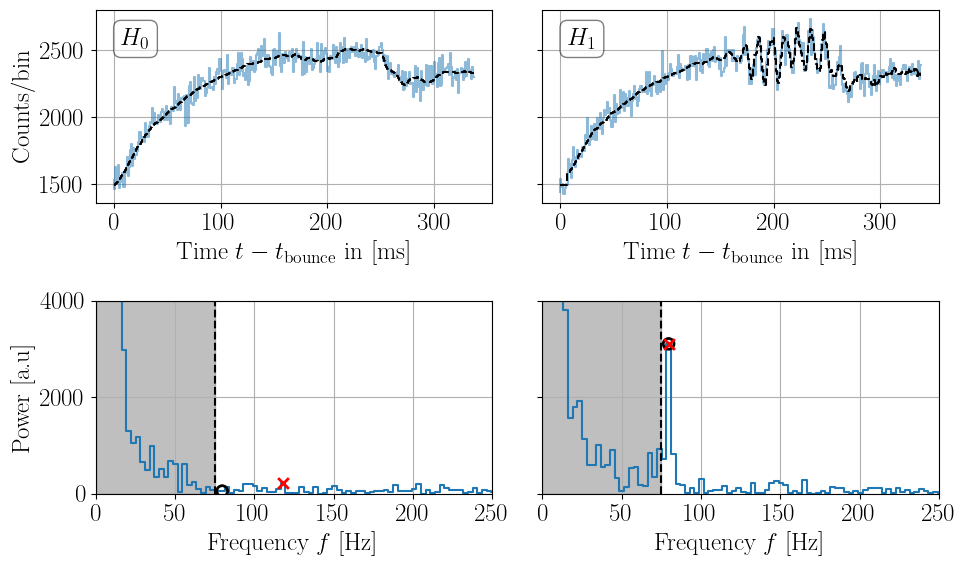

In [152]:
fs = 18
plt.rcParams["font.size"] = fs
det = "ic86"

freq_cut = freq_win[0]
freq_0 = 80 *u.Hz

texts = [r"$H_0$", r"$H_1$"] # r"$H_1$ w/o noise"

ttime = ana.sim.time.to(u.ms)

hits_null = ana._sig_sample["null"][det][0] + ana._bkg[det][0]
hits_signal = ana._sig_sample["signal"][det][1] + ana._bkg[det][1]

hits_null0 = ana._sig["null"][det] + ana._avg_bkg[det]
hits_signal0 = ana._sig["signal"][det] + ana._avg_bkg[det]


hits = np.array([hits_null, hits_signal]) # hits_sig,
hits0 = np.array([hits_null0, hits_signal0]) # hits_sig0, 

freq, fft_null = get_fft(ttime, hits_null, fft_para=fft_para)
_, fft_signal = get_fft(ttime, hits_signal, fft_para=fft_para)


ffts = np.array([fft_null, fft_signal]) #stf_sig, 


fig, ax = plt.subplots(2,2, figsize = (10,6), sharey="row")

fig.subplots_adjust(wspace=0, hspace=0)
ax = ax.ravel()


for i in range(4):
    j = i%2

    if i < 2:

        ax[i].step(ttime, hits[j], color = 'C0', ls = '-', alpha = 0.5)
        ax[i].step(ttime, hits0[j], color = 'k', ls = '--',  zorder = 10)

        ax[i].text(0.1, 0.85, s = texts[j], transform=ax[i].transAxes, va='center', ha = 'center', 
                   bbox= dict(boxstyle='round', facecolor='white', alpha=0.5))

        ax[i].set_xlabel(r'Time $t - t_{\mathrm{bounce}}$ in [ms]')

        #ax[i].set_xlim(0,1000)

        ax[i].tick_params()
        ax[i].grid()


    if i >= 2:

        ax[i].step(freq, ffts[j], color = "C0", ls = '-', where="mid")
        ax[i].axvline(freq_cut.value, color = "k", ls = "--")
        ax[i].axvspan(0, freq_cut.value, color = "k", alpha = 0.25)

        freq_mask = freq > freq_cut
        idx_max = np.argmax(ffts[j][freq_mask])
        ax[i].scatter(freq[freq_mask][idx_max], ffts[j][freq_mask][idx_max], color = "r", marker = "x", s = 60, lw = 2, zorder = 10)
        ax[i].scatter(freq[np.argmin(np.abs(freq-freq_0))], ffts[j][np.argmin(np.abs(freq-freq_0))], color = "k", marker = "o", fc = "None", s = 60, lw = 2, zorder = 5)

        ax[i].set_xlabel(r'Frequency $f$ [Hz]')

        ax[i].set_xlim(0,250)
        ax[i].set_ylim(0,4000)

        ax[i].tick_params()
        ax[i].grid()

ax[0].set_ylabel('Counts/bin')
ax[2].set_ylabel(r'Power [a.u]')


ax[0].set_yticks([1500, 2000, 2500])


plt.tight_layout()
#plt.savefig("/home/jakob/Desktop/figures/Part II/ProspectSASI/sasi_hypothesis.pdf", bbox_inches = "tight")

In [124]:
from scripts import background_trials

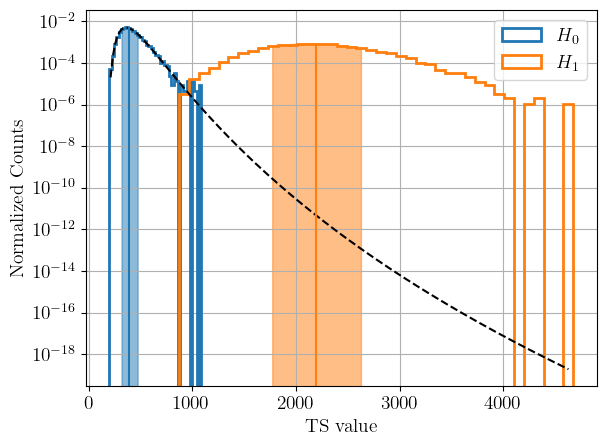

In [154]:
from scripts.plthelper import plot_ts

plot_ts(ana.ts, bkg_distr="lognorm")
plt.yscale("log")
#plt.xlim(0, 3000)

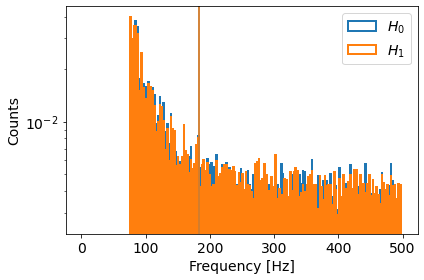

In [19]:
plot_fit_freq(ana.ffit)

In [20]:
dist_range = np.arange(0.2,3,0.2) * u.kpc
Zscore, Ts_stat, Freq_stat = ana.dist_scan(dist_range, mode = "FFT", trials = trials, ft_para = fft_para, model = "generic", verbose = "debug")

Distance: 0.2 kpc


TypeError: Analysis.run() missing 2 required positional arguments: 'bkg_var' and 'trials'

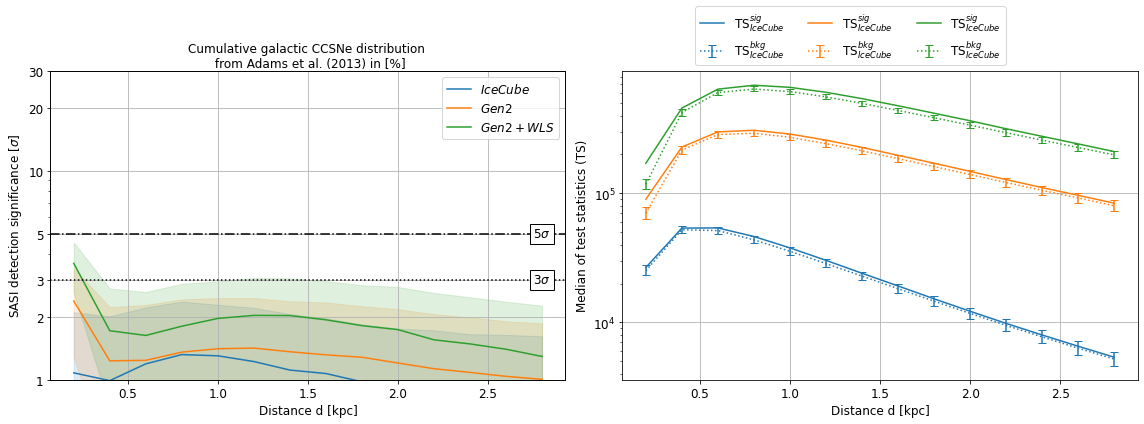

In [21]:
plot_significance(dist_range, Zscore, Ts_stat)

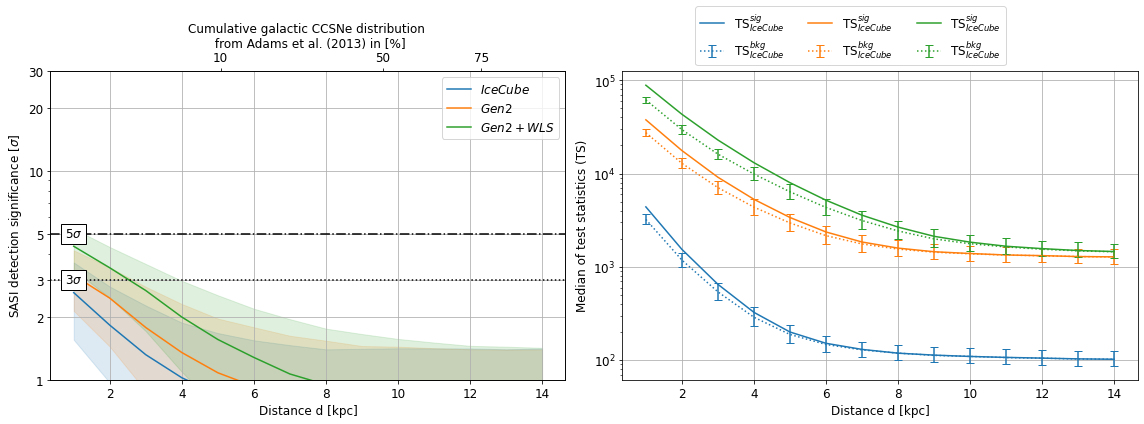

In [ ]:
#plot_significance(disignalst_range, Zscore, Ts_stat) # 1% amplitude

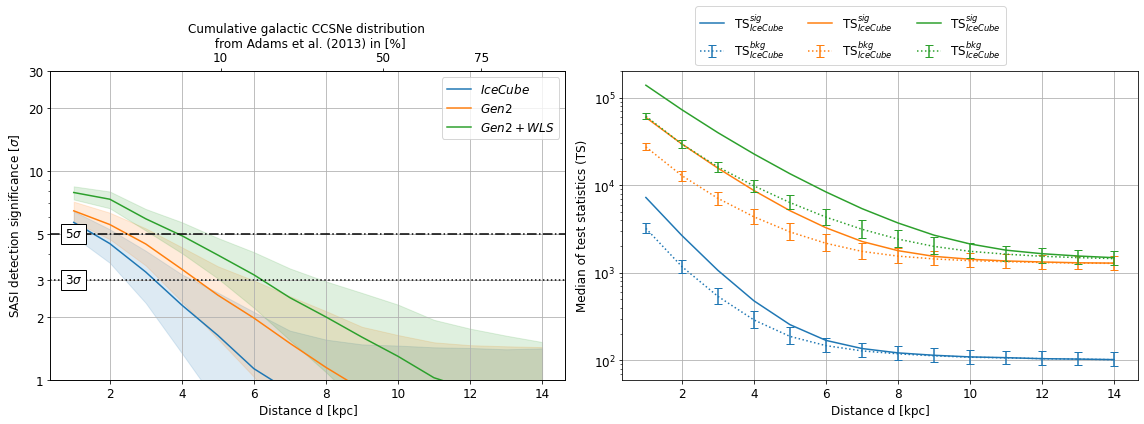

In [ ]:
#plot_significance(dist_range, Zscore, Ts_stat) # 2% amplitude

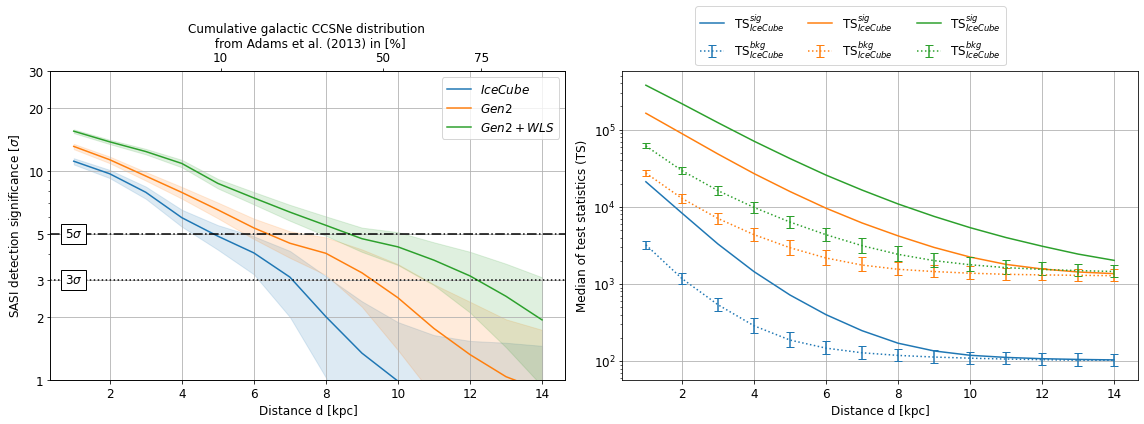

In [ ]:
#plot_significance(dist_range, Zscore, Ts_stat) # 5% amplitude

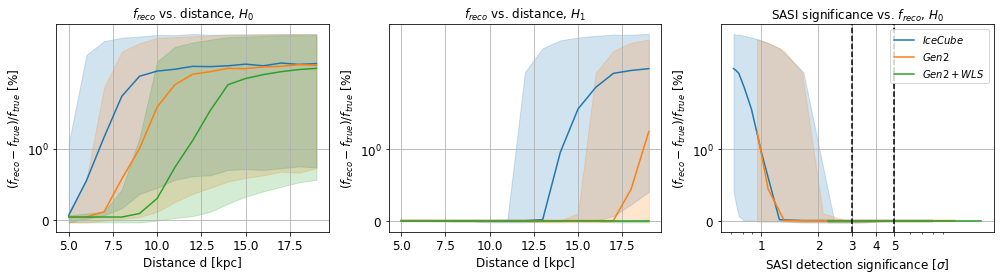

In [ ]:
# Plot reco freq vs. distance and significance

from matplotlib.ticker import ScalarFormatter
freq_stat = Freq_stat
zscore = Zscore
f0 = 80
fig, ax = plt.subplots(1,3, figsize = (14,4))
ax = ax.ravel()

labels = [r'$IceCube$', r'$Gen2$', r'$Gen2+WLS$']
colors = ['C0', 'C1', 'C2']


for i, det in enumerate(["ic86", "gen2", "wls"]):

    ax[0].plot(dist_range, np.abs(freq_stat["null"][det][0]-f0)/f0, label=labels[i], color = colors[i])
    ax[0].fill_between(dist_range.value, (freq_stat["null"][det][1]-f0)/f0, (freq_stat["null"][det][2]-f0)/f0, color = colors[i], alpha = 0.2)

    ax[1].plot(dist_range, np.abs(freq_stat["signal"][det][0]-f0)/f0, label=labels[i], color = colors[i])
    ax[1].fill_between(dist_range.value, (freq_stat["signal"][det][1]-f0)/f0, (freq_stat["signal"][det][2]-f0)/f0, color = colors[i], alpha = 0.2)

    ax[2].plot(zscore[det][0], np.abs(freq_stat["signal"][det][0]-f0)/f0, label=labels[i], color = colors[i])
    ax[2].fill_between(zscore[det][0], (freq_stat["signal"][det][1]-f0)/f0, (freq_stat["signal"][det][2]-f0)/f0, color = colors[i], alpha = 0.2)


for i in range(3):
    ax[i].set_xlabel('Distance d [kpc]', fontsize = 12)
    ax[i].set_ylabel(r'$(f_{reco} - f_{true})/f_{true}$ [%]' , fontsize = 12)
    ax[i].set_yscale("symlog")
    ax[i].tick_params(labelsize = 12)

    ax[i].grid()
    #ax[i].legend(loc='upper right', fontsize = 12)


ax[0].set_title(r"$f_{reco}$ vs. distance, $H_0$")
ax[1].set_title(r"$f_{reco}$ vs. distance, $H_1$")
ax[2].set_title(r"SASI significance vs. $f_{reco}$, $H_0$")



ax[2].set_xlabel(r'SASI detection significance [$\sigma$]' , fontsize = 12)
ax[2].legend()

ax[2].set_xscale("log")
ax[2].set_xticks([1,2,3,4,5])
ax[2].get_xaxis().set_major_formatter(ScalarFormatter())

ax[2].axvline(3, color = "k", ls = "--")
ax[2].axvline(5, color = "k", ls = "--")

plt.tight_layout()